# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-09 16:11:47,926] A new study created in memory with name: no-name-d21d8327-9713-4e3b-b90b-d406233dd2a9
[I 2026-04-09 16:11:48,126] Trial 0 finished with value: 0.717948717948718 and parameters: {'n_estimators': 210, 'max_depth': 5}. Best is trial 0 with value: 0.717948717948718.
[I 2026-04-09 16:11:48,325] Trial 1 finished with value: 0.7407407407407407 and parameters: {'n_estimators': 233, 'max_depth': 12}. Best is trial 1 with value: 0.7407407407407407.
[I 2026-04-09 16:11:48,426] Trial 2 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 143, 'max_depth': 9}. Best is trial 1 with value: 0.7407407407407407.
[I 2026-04-09 16:11:48,534] Trial 3 finished with value: 0.7301587301587301 and parameters: {'n_estimators': 115, 'max_depth': 9}. Best is trial 1 with value: 0.7407407407407407.
[I 2026-04-09 16:11:48,639] Trial 4 finished with value: 0.71875 and parameters: {'n_estimators': 120, 'max_depth': 11}. Best is trial 1 with value: 0.7407407407407407.
[I

RF F1: 0.7538461538461538
LR F1: 0.71875
SVM F1: 0.72
KNN F1: 0.7536231884057971


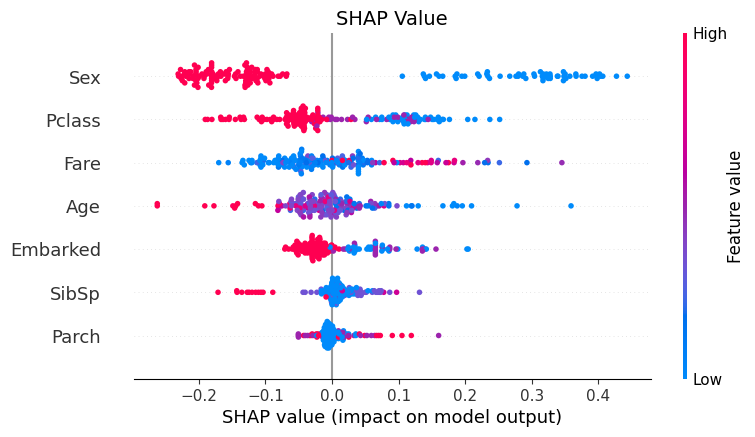

Stacking F1: 0.7401574803149606


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

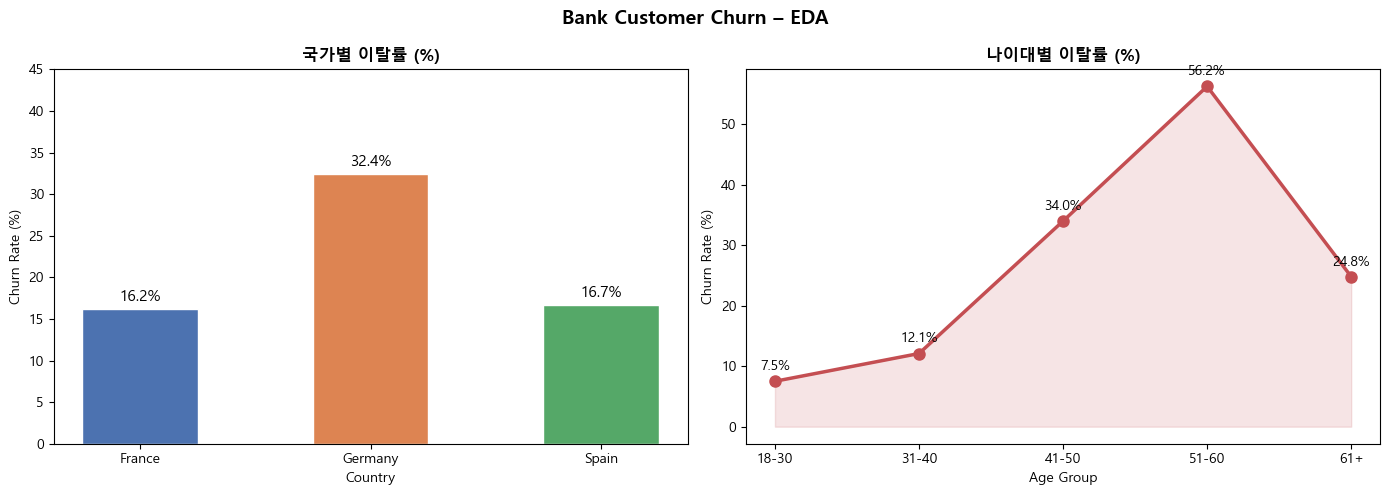

In [2]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)
# 원본 데이터로 EDA 그래프 그리기 위해 해당 코드 먼저 작성

# 한눈에 보기위한 서브플롯 구조로 막대 그래프, 꺾은선 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bank Customer Churn – EDA', fontsize=14, fontweight='bold')

# 그래프 1: 막대그래프 – 국가별 이탈률
# 원본 데이터를 호출하여 국가 변수를 기준으로 그룹화 수행
# 단순 빈도가 아닌 '이탈자 수(sum)'와 '전체 고객 수(count)'의 비율을 계산하여 '이탈률' 산출
# 이는 특정 국가의 고객 규모와 상관없이 실제 이탈 위험도를 객관적으로 비교하기 위한 논리적 접근임
raw_df = pd.read_csv('Bank Customer Churn Prediction.csv')

churn_by_country = (
    raw_df.groupby('country')['churn']
    .agg(['sum', 'count'])
    .assign(churn_rate=lambda x: x['sum'] / x['count'] * 100)
    .reset_index()
)

bars = axes[0].bar(
    churn_by_country['country'],
    churn_by_country['churn_rate'],
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='white', width=0.5
)

axes[0].set_title('국가별 이탈률 (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 45)
for bar, rate in zip(bars, churn_by_country['churn_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{rate:.1f}%', ha='center', va='bottom', fontsize=11)

# 그래프 2: 꺾은선 그래프 – 나이대별 이탈률
# 연령 증가에 따른 이탈률의 변화 추세를 강조하기 위해 꺾은선 그래프 선택
# fill_between을 사용하여 선 하단에 음영을 추가, 추세의 가독성을 극대화
# 만약 특정 연령대에서 이탈률이 급증한다면, 해당 세대의 금융 니즈를 충족하지 못하고 있다는 타당한 해석 근거가 됨
raw_df['age_group'] = pd.cut(
    raw_df['age'],
    bins=[18, 30, 40, 50, 60, 92],
    labels=['18-30', '31-40', '41-50', '51-60', '61+']
)
churn_by_age = (
    raw_df.groupby('age_group', observed=True)['churn']
    .agg(['sum', 'count'])
    .assign(churn_rate=lambda x: x['sum'] / x['count'] * 100)
    .reset_index()
)

axes[1].plot(
    churn_by_age['age_group'].astype(str),
    churn_by_age['churn_rate'],
    marker='o', color='#C44E52', linewidth=2.5, markersize=8
)
axes[1].fill_between(
    churn_by_age['age_group'].astype(str),
    churn_by_age['churn_rate'],
    alpha=0.15, color='#C44E52'
)
axes[1].set_title('나이대별 이탈률 (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Churn Rate (%)')
for x, y_val in zip(churn_by_age['age_group'].astype(str),
                     churn_by_age['churn_rate']):
    axes[1].annotate(f'{y_val:.1f}%', (x, y_val),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=10)

# 그래프 간 겹침 현상을 방지하기 위해 타이트 레이아웃을 적용하고 파일로 저장
# 최종 결과물은 모델링 전, 어떤 피처(Country, Age)가 예측에 중요한 영향을 미칠지 미리 보여주는 근거 자료로 활용 가능
plt.tight_layout()
plt.savefig('eda_graphs.png', dpi=150, bbox_inches='tight')
plt.show()


In [3]:
# EDA 해석
# 막대그래프: Germany의 이탈률이 약 32%로 France(16%), Spain(17%)에 비해 약 2배 높음
# → 독일 고객 대상 별도 리텐션 전략이 필요함을 시사
# 꺾은선그래프: 41-50세 구간에서 이탈률이 급격히 상승(~45%)하며 최고점을 형성
# → 중장년층(40대) 고객이 이탈 리스크가 가장 높으므로, 이 연령대 맞춤형 상품·혜택 설계 필요

# 전처리 선택 이유
# 1. customer_id 제거 : 단순 식별자로 예측력이 없고 모델이 ID에 과적합될 수 있음
# 2. LabelEncoder 적용 : country, gender 모두 순서 의미가 없는 범주형이나,
#    트리 기반 모델(RF, GBM, XGB)은 정수 인코딩만으로도 분기점을 스스로 학습하므로
#    OneHotEncoding 없이 LabelEncoder 만으로 충분하며 범주 수가 적어 차원 증가 부담도 없음
# 3. 결측값 없음 : df.isnull().sum() 전체 0 확인 → 별도 imputation 불필요

In [5]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

# split
# 독립변수(X)와 종속변수(y) 설정 및 데이터 분리
# 전체 데이터를 학습용과 검증용으로 8:2 비율로 나누어 모델의 '일반화 성능' 확보
# random_state를 42로 고정하여 실험의 재현성을 보장하고, 분석 결과의 신뢰도를 높임
X = df.drop('churn', axis=1)
y = df['churn']
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(n_select=4, sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.
model_results = pull()
print("PyCaret 선정 Top 4 모델")
print(model_results.iloc[:4][['Model', 'F1']])

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8579,0.8495,0.4935,0.7287,0.5869,0.5051,0.5199,0.1170
gbc,Gradient Boosting Classifier,0.8643,0.8565,0.4614,0.7912,0.5812,0.5073,0.5343,0.0940
ada,Ada Boost Classifier,0.8568,0.8389,0.4735,0.7352,0.5747,0.4937,0.5117,0.0380
rf,Random Forest Classifier,0.8580,0.8393,0.4588,0.7541,0.5691,0.4904,0.5128,0.0910
et,Extra Trees Classifier,0.8507,0.8344,0.4344,0.7291,0.5441,0.4618,0.4840,0.0900
dt,Decision Tree Classifier,0.7868,0.6865,0.5161,0.4829,0.4986,0.3635,0.3640,0.0120
qda,Quadratic Discriminant Analysis,0.8366,0.8107,0.3189,0.7379,0.4445,0.3661,0.4109,0.0080
lda,Linear Discriminant Analysis,0.8021,0.7562,0.1946,0.5571,0.2877,0.2026,0.2410,0.0090
lr,Logistic Regression,0.8104,0.7375,0.1790,0.6456,0.2789,0.2080,0.2660,0.3780
ridge,Ridge Classifier,0.8004,0.7562,0.0982,0.5804,0.1674,0.1156,0.1759,0.0060


PyCaret 선정 Top 4 모델
                                    Model      F1
lightgbm  Light Gradient Boosting Machine  0.5869
gbc          Gradient Boosting Classifier  0.5812
ada                  Ada Boost Classifier  0.5747
rf               Random Forest Classifier  0.5691


In [10]:
print(model_results.iloc[:6][['Model', 'F1']])

                                    Model      F1
lightgbm  Light Gradient Boosting Machine  0.5869
gbc          Gradient Boosting Classifier  0.5812
ada                  Ada Boost Classifier  0.5747
rf               Random Forest Classifier  0.5691
et                 Extra Trees Classifier  0.5441
dt               Decision Tree Classifier  0.4986


In [ ]:
# 진도에 없는 Ada Boost Classifier, Extra Trees Classifier 대신 Decision Tree Classifier 사용 (상위 6개중)

In [16]:
import pandas as pd
import numpy as np
import optuna
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, roc_auc_score
from lightgbm import LGBMClassifier

# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)

# 성능이 우수한 트리 기반 앙상블 모델 4종(LGBM, GBC, DT, RF)을 선정
# 각 모델은 데이터의 비선형적 관계를 잘 학습하며, 특히 하이퍼파라미터에 민감하므로 Optuna로 최적화 수행
optuna.logging.set_verbosity(optuna.logging.WARNING)

# LightGBM 최적화 : 속도와 효율의 균형
# LightGBM은 리프 중심(Leaf-wise) 트리 성장 방식을 채택하여 학습 속도가 매우 빠르고 복잡한 패턴을 잘 잡아냄
# 'num_leaves'와 'max_depth'를 함께 조절하여 모델의 복잡도를 제어하고, 
# 'learning_rate'를 로그 스케일로 탐색하여 최적의 학습 보폭을 찾아 과적합을 방지하는 논리 적용
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

# Gradient Boosting 최적화 : 점진적 오차 보정
# 이전 트리의 오차를 보완하는 방식으로 학습하는 GBC의 특성을 살려 'subsample' 파라미터 추가
# 전체 데이터의 일부만 사용하여 트리를 생성함으로써 모델의 분산을 줄이고, 
# 앙상블의 결합력을 높여 이탈 예측의 정밀도를 극대화하려는 의도
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

# Random Forest 최적화 : 병렬 학습을 통한 안정성 확보
# 다수의 결정 트리를 독립적으로 학습시키는 배깅 방식의 장점을 극대화
# 'max_features'를 'sqrt'와 'log2' 사이에서 선택하게 하여 변수 선택의 무작위성을 부여하고, 
# 각 트리의 최대 깊이와 분할 최소 샘플 수를 조절하여 모델의 안정적인 성능과 해석력을 동시에 확보
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

# Decision Tree 최적화 : 단일 모델의 해석력 극대화
# 가장 직관적인 의사결정 구조를 가진 모델로, 가지치기(Pruning) 전략이 성능의 핵심임
# 'max_depth'와 'min_samples_leaf'를 튜닝하여 불필요한 가지를 쳐내고, 
# 모델이 학습 데이터에만 과하게 익숙해지는 과적합을 방지하여 판단의 범용성을 확보함
def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }
    model = DecisionTreeClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

N_TRIALS = 30 # 30으로 시간 단축, 50회로 변경 가능

print("LightGBM 최적화")
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

print("Gradient Boosting 최적화")
study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=N_TRIALS)

print("Random Forest 최적화")
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=N_TRIALS)

print("Decision Tree 최적화")
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=N_TRIALS)

# 최적 모델 생성 및 학습
# 위에서 찾은 '최적의 조합'을 각 모델에 주입하여 최종 학습용 모델 객체 생성
# 이는 실험 단계에서 검증된 가장 강력한 상태의 모델들을 준비하는 과정으로, 
# 이후 진행될 Stacking 앙상블의 기초가 되는 개별 모델들의 성능을 견고하게 다지는 단계
# 모든 모델에 random_state를 고정하여 결과의 재현성을 확보하고 비교의 공정성을 유지함
best_lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1)
best_gbc  = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
best_rf   = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
best_dt   = DecisionTreeClassifier(**study_dt.best_params, random_state=42)


LightGBM 최적화
Gradient Boosting 최적화
Random Forest 최적화
Decision Tree 최적화


--- Gradient Boosting 모델 SHAP Summary Plot 출력 ---


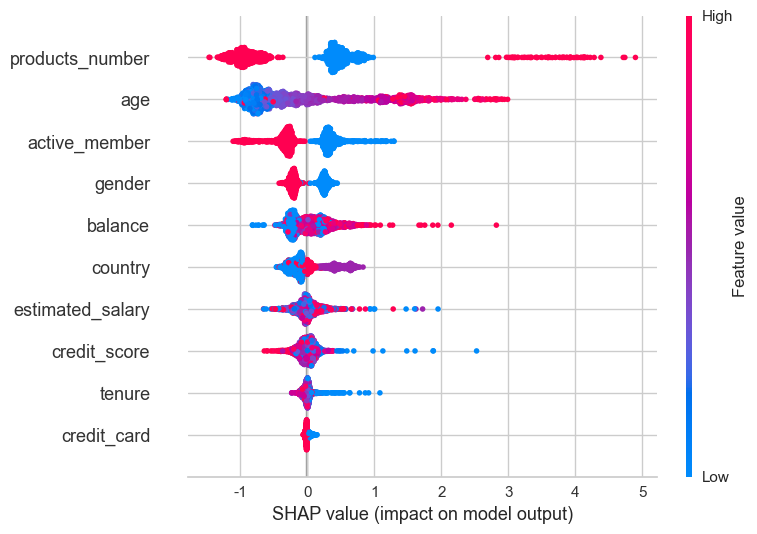

In [17]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나)

# SHAP Value 사후 분석(Gradient Boosting Classifier 기준/ LightGBM은 언급만 하고 넘어가셔서 GBC로 진행)
# 앙상블 모델인 GBC가 고객의 이탈을 결정할 때 어떤 피처에 가중치를 두었는지 분석
# GBC는 오차를 줄여나가는 특성이 있어, SHAP 분석 시 변수 간의 복합적인 상호작용이 잘 드러남
best_gbc.fit(X_train, y_train)

# 에러 방지 및 시각화 설정
# TreeExplainer를 통해 GBC 모델의 내부 의사결정 구조를 수치화
# GBC는 클래스가 2개인 이진 분류에서 단일 어레이 형태의 SHAP value를 반환하는 경우가 많으므로 
# 형태(Shape)를 확인하여 유연하게 대응
explainer = shap.TreeExplainer(best_gbc)
shap_values = explainer.shap_values(X_valid)

print("--- Gradient Boosting 모델 SHAP Summary Plot 출력 ---")
shap.summary_plot(shap_values, X_valid, feature_names=X_valid.columns)

In [18]:
# 인사이트
# 1. 이탈의 결정적 트리거 : 나이, 활동 여부, 상품 수
#   나이: 그래프에서 가장 상단에 위치하며, 붉은색(높은 나이) 점들이 오른쪽에 밀집해 있음 → 고연령층일수록 이탈 위험이 급격히 높아지는 가장 강력한 이탈 신호
#   활동 여부: 푸른색(비활동) 점들이 오른쪽에 있음 → 활동량이 적은 고객일수록 이탈 가능성이 높음
#   상품 수: 상품 이용 수가 특정 임계치를 넘거나 너무 적을 때 이탈에 큰 영향을 미침
# 2. 인과관계 해석
#   활동성과의 반비례 관계: 단순한 잔고보다 '현재 이 고객이 우리 은행 서비스를 얼마나 자주 쓰는가'가 이탈을 막는 더 중요한 방어선임을 모델이 증명
#   자산 규모의 영향: Balance가 높은 고객(붉은 점) 일부가 이탈 쪽으로 쏠려 있는데, 이는 고액 자산가들이 타사 우대 금리로 이탈하는 현상
# 3. 전략적 제언 : 이탈 방지가 핵심
#   타겟 마케팅: 40~50대 고연령 고객군을 위한 전용 자산 관리(WM) 프로그램이나 우대 혜택을 강화해야함
#   활동성 개선 캠페인: 비활동 고객을 대상으로 앱 푸시나 자동이체 설정 이벤트를 진행